In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [12]:
df = pd.read_csv('data/people_move.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   행정구역(시군구)별   18 non-null     str  
 1   2026.01      19 non-null     str  
 2   Unnamed: 2   19 non-null     str  
 3   Unnamed: 3   19 non-null     str  
 4   Unnamed: 4   19 non-null     str  
 5   Unnamed: 5   19 non-null     str  
 6   Unnamed: 6   19 non-null     str  
 7   Unnamed: 7   19 non-null     str  
 8   Unnamed: 8   19 non-null     str  
 9   2026.02      19 non-null     str  
 10  Unnamed: 10  19 non-null     str  
 11  Unnamed: 11  19 non-null     str  
 12  Unnamed: 12  19 non-null     str  
 13  Unnamed: 13  19 non-null     str  
 14  Unnamed: 14  19 non-null     str  
 15  Unnamed: 15  19 non-null     str  
 16  Unnamed: 16  19 non-null     str  
 17  2026.03      19 non-null     str  
 18  Unnamed: 18  19 non-null     str  
 19  Unnamed: 19  19 non-null     str  
 20  Unnamed: 20  19 non-nul

In [17]:
df = pd.read_csv('data/people_move.csv', header=[0,1])
print(df.columns)

MultiIndex([(         '행정구역(시군구)별', 'Unnamed: 0_level_1'),
            (            '2026.01',            '총전입 (명)'),
            ( 'Unnamed: 2_level_0',            '총전출 (명)'),
            ( 'Unnamed: 3_level_0',            '순이동 (명)'),
            ( 'Unnamed: 4_level_0',     '시도내이동-시군구내 (명)'),
            ( 'Unnamed: 5_level_0',  '시도내이동-시군구간 전입 (명)'),
            ( 'Unnamed: 6_level_0',  '시도내이동-시군구간 전출 (명)'),
            ( 'Unnamed: 7_level_0',          '시도간전입 (명)'),
            ( 'Unnamed: 8_level_0',          '시도간전출 (명)'),
            (            '2026.02',            '총전입 (명)'),
            ('Unnamed: 10_level_0',            '총전출 (명)'),
            ('Unnamed: 11_level_0',            '순이동 (명)'),
            ('Unnamed: 12_level_0',     '시도내이동-시군구내 (명)'),
            ('Unnamed: 13_level_0',  '시도내이동-시군구간 전입 (명)'),
            ('Unnamed: 14_level_0',  '시도내이동-시군구간 전출 (명)'),
            ('Unnamed: 15_level_0',          '시도간전입 (명)'),
            ('Unnamed: 16_level_0',          '시도간전출 (명)'

In [22]:
net_df = df[
    [
        ('행정구역(시군구)별', 'Unnamed: 0_level_1'),
        ('Unnamed: 3_level_0', '순이동 (명)'),
        ('Unnamed: 11_level_0', '순이동 (명)'),
        ('Unnamed: 19_level_0', '순이동 (명)')
    ]
]

net_df.columns = [
    'region',
    'net_01',
    'net_02',
    'net_03'
]

net_df.head()

,region,net_01,net_02,net_03
0,전국,0,0,0
1,서울특별시,-105,"4,227",-167
2,부산광역시,-844,157,-821
3,대구광역시,-251,-425,"-1,049"
4,인천광역시,"1,283",871,"1,586"


In [24]:
net_df['net_01'] = pd.to_numeric(
    net_df['net_01'].str.replace(',', '')
)

net_df['net_02'] = pd.to_numeric(
    net_df['net_02'].str.replace(',', '')
)

net_df['net_03'] = pd.to_numeric(
    net_df['net_03'].str.replace(',', '')
)

In [29]:
net_df['avg_net_migration'] = (
    net_df[
        ['net_01', 'net_02', 'net_03']
    ].mean(axis=1)
)

net_df.head()

,region,net_01,net_02,net_03,avg_net_migration
0,전국,0,0,0,0.000000
1,서울특별시,-105,4227,-167,1318.333333
2,부산광역시,-844,157,-821,-502.666667
3,대구광역시,-251,-425,-1049,-575.000000
4,인천광역시,1283,871,1586,1246.666667


In [ ]:
net_df.sort_values(
    by='avg_net_migration'
).head(20) 

#평균적으로 사람이 많이 빠져나간 지역

,region,net_01,net_02,net_03,avg_net_migration
16,경상남도,-605,-3454,-1648,-1902.333333
5,광주광역시,-1139,-1287,-1547,-1324.333333
15,경상북도,-1533,-2011,64,-1160.000000
7,울산광역시,-612,-1410,-1143,-1055.000000
13,전북특별자치도,-589,-894,-299,-594.000000
3,대구광역시,-251,-425,-1049,-575.000000
2,부산광역시,-844,157,-821,-502.666667
14,전라남도,-79,-841,-578,-499.333333
17,제주특별자치도,-655,-440,-247,-447.333333
8,세종특별자치시,-633,-351,-310,-431.333333


In [ ]:
net_df = net_df[
    net_df['region'].str.contains('시|군|구')
]

,region,net_01,net_02,net_03,avg_net_migration
1,서울특별시,-105,4227,-167,1318.333333
2,부산광역시,-844,157,-821,-502.666667
3,대구광역시,-251,-425,-1049,-575.000000
4,인천광역시,1283,871,1586,1246.666667
5,광주광역시,-1139,-1287,-1547,-1324.333333


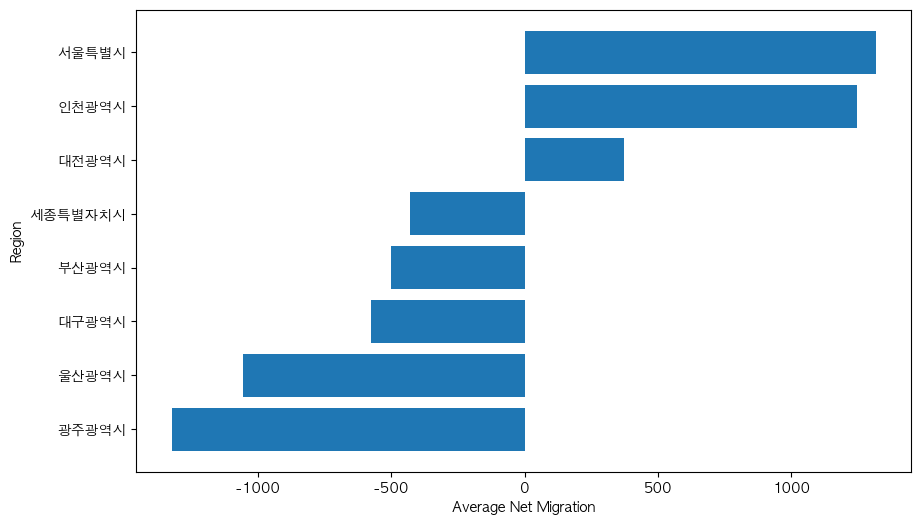

In [36]:
import matplotlib.pyplot as plt

top10 = net_df.sort_values(
    by='avg_net_migration'
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['region'],
    top10['avg_net_migration']
)

plt.xlabel('Average Net Migration')
plt.ylabel('Region')

plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/move.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 41 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   행정구역(시군구)별   18 non-null     str  
 1   2021         19 non-null     str  
 2   Unnamed: 2   19 non-null     str  
 3   Unnamed: 3   19 non-null     str  
 4   Unnamed: 4   19 non-null     str  
 5   Unnamed: 5   19 non-null     str  
 6   Unnamed: 6   19 non-null     str  
 7   Unnamed: 7   19 non-null     str  
 8   Unnamed: 8   19 non-null     str  
 9   2022         19 non-null     str  
 10  Unnamed: 10  19 non-null     str  
 11  Unnamed: 11  19 non-null     str  
 12  Unnamed: 12  19 non-null     str  
 13  Unnamed: 13  19 non-null     str  
 14  Unnamed: 14  19 non-null     str  
 15  Unnamed: 15  19 non-null     str  
 16  Unnamed: 16  19 non-null     str  
 17  2023         19 non-null     str  
 18  Unnamed: 18  19 non-null     str  
 19  Unnamed: 19  19 non-null     str  
 20  Unnamed: 20  19 non-nul

In [7]:
net_df = df.iloc[1:].copy()

net_df = net_df[
    [
        '행정구역(시군구)별',
        'Unnamed: 3',
        'Unnamed: 11',
        'Unnamed: 19',
        'Unnamed: 27',
        'Unnamed: 35'
    ]
]

net_df.columns = [
    'region',
    'net_2021',
    'net_2022',
    'net_2023',
    'net_2024',
    'net_2025'
]

net_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 1 to 18
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   region    18 non-null     str  
 1   net_2021  18 non-null     str  
 2   net_2022  18 non-null     str  
 3   net_2023  18 non-null     str  
 4   net_2024  18 non-null     str  
 5   net_2025  18 non-null     str  
dtypes: str(6)
memory usage: 996.0 bytes
